# **G345 ANÁLISIS DE DATOS**

# ANÁLISIS DE TARIFAS Y COSTOS DE ENERGÍA ELÉCTRICA PARA EL MERCADO REGULADO

# Nombre y cédula de los integrantes

- Ximena Orbes Arias - 1033099573

- Juan Esteban Lame Vasquez - 1142514863

- Isabella Cardona Betancourt - 1087992113

- Meycol Kleym Quintero Castaño - 1089931356

# Preparación del entorno

In [112]:
# (Opcional) Instalar dependencias en este notebook
# Si ya están instaladas, esta celda terminará rápido.
# %pip -q install pandas numpy matplotlib

In [113]:
# Se importan las librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import statsmodels.api as sm
warnings.filterwarnings("ignore")

# Base de datos: Tarifas y Costos de Energía Eléctrica para el Mercado Regulado

## Acerca de este archivo

En cumplimiento de las Leyes 142 de 1994 y 1955 de 2019, y las Resoluciones CREG (Comisión de Regulación de Energía y Gas) 058 de 2000, 119 de 2007, 105 de 2009, 156 de 2009, 173 de 2011, 152 de 2018 y 101028 de 2023, este conjunto de datos proporciona información detallada sobre las tarifas y costos de energía eléctrica en el mercado regulado.

Los datos incluyen información sobre las tarifas de energía, el costo de compra de energía, los cargos de transporte en los sistemas de transmisión y distribución, los márgenes de comercialización, costos relacionados con generación y pérdidas, así como otros factores operativos que influyen en el precio final que los usuarios deben pagar. Además, se desglosan por tipo de propiedad (Operador de Red, Propiedad Compartida, Propiedad Cliente) y se dividen en diferentes niveles de tensión eléctrica.

Este conjunto de datos está diseñado para facilitar el análisis de las tarifas y costos eléctricos en distintas regiones y periodos, proporcionando una visión clara de los componentes que afectan el precio de la energía para los usuarios del mercado regulado.

Los datos abarcan el periodo de enero de 2024 a septiembre de 2025.

## Diccionario de datos

- *Año:* El año en el que se registran los datos sobre tarifas y costos de energía eléctrica. Ejemplo: 2024
- *Priodo:* El mes o período específico dentro del año al que corresponde la tarifa o costo de energía.
- *Operador de red:* La empresa responsable de la distribución de energía eléctrica en una zona específica.
- *Nivel:* La categoría del servicio eléctrico, que puede incluir diferentes tipos de tensión como Baja Tensión (B.T.), Media Tensión (M.T.) o Alta Tensión (A.T.).
- *CU Total:* El costo total por kilovatio hora (kWh) que los usuarios deben pagar por la electricidad, incluyendo todos los cargos.
- *Costo Compra (Gm,i):* El precio que paga el operador de red por la electricidad comprada a los generadores.
- *Cargo Transporte STN (Tm):* El costo asociado al transporte de electricidad a través del Sistema de Transmisión Nacional (STN), que es la red de alta tensión que lleva la electricidad de los generadores a las subestaciones.
- *Cargo Transporte SDL (Dn,m):* El costo asociado al transporte de electricidad en el Sistema de Distribución Local (SDL), que distribuye la electricidad desde las subestaciones hasta los usuarios finales.
- *Margen Comercialización (CVm,i,j):* El costo adicional que cubre la comercialización de la electricidad, incluyendo los gastos de operación y transacción del operador de red.
- *Costo G, T, Pérdidas (PRn,m):* Los costos asociados a la generación, transmisión y pérdidas de energía durante su transporte por la red, debido a la resistencia y otros factores.

## Archivo CSV

Se importa archivo CSV que contiene la información tarifaria del mercado regulado.
Se verifica la existencia del archivo y se muestran las dimensiones iniciales del dataset.

In [114]:
# Ruta relativa: este notebook está en la misma carpeta que DATASET.csv
ruta_csv = Path("Tarifas_y_Costos_de_Energía_Eléctrica_para_el_Mercado_Regulado.csv")

try:
    if not ruta_csv.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta_csv.resolve()}")

    df = pd.read_csv(ruta_csv, low_memory=False)
except (OSError, FileNotFoundError) as err:
    print(f"No se pudo abrir el archivo. Error: {err}.")
else:
    print("Archivo cargado con éxito en el dataframe.")
    print("Dimensiones:", df.shape)
    display(df.head())

Archivo cargado con éxito en el dataframe.
Dimensiones: (415, 13)


,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)"
0,"2,025",Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.813
1,"2,025",Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.813
2,"2,025",Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.813
3,"2,025",Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.813
4,"2,025",Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.3,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.813


# Limpieza y Preparación de Datos

## Exploración incial del CSV

Se inspeccionan los tipos de datos, la presencia de valores nulos, duplicados y cardinalidad de cada variable para identificar necesidades de limpieza.

In [115]:
# Observamos los tipos de datos que se tienen en la base de datos para empezar a visualizar y tener en cuenta
# qué columnas modificar

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Año                                415 non-null    object 
 1   Periodo                            415 non-null    object 
 2   Operador de red                    415 non-null    object 
 3   Nivel                              415 non-null    object 
 4   CU Total                           415 non-null    object 
 5   Costo Compra (Gm,i)                415 non-null    float64
 6   Cargo Transporte STN (Tm)          415 non-null    float64
 7   Cargo Transporte SDL (Dn,m)        415 non-null    float64
 8   Margen Comercialización (CVm,i,j)  415 non-null    float64
 9   Costo G, T, Pérdidas (PRn,m)       415 non-null    float64
 10  Restricciones (Rm)                 415 non-null    float64
 11  COT                                415 non-null    float64

In [116]:
# Si necesitamos llamar una función en una columna que requiera el nombre de esta, podemos venir a este Index de
# columnas para facilitar la busqueda del nombre, este también sería una versión más simple y enfocada a lo necesario de df.info()

for i, col in enumerate(df.columns):
    nulos_con_null = df[col].isnull().sum()
    nulos_con_nan = df[col].isna().sum()
    print(f"""Columna {i}: '{col}' → {df[col].dtype} | Nulos: {nulos_con_null} (null), {nulos_con_nan} (nan)  
Cantidad de datos únicos: {df[col].nunique()}
Duplicados: {df[col].duplicated().sum()}
""")

Columna 0: 'Año' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 2
Duplicados: 413

Columna 1: 'Periodo' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 12
Duplicados: 403

Columna 2: 'Operador de red' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 6
Duplicados: 409

Columna 3: 'Nivel' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 7
Duplicados: 408

Columna 4: 'CU Total' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 412
Duplicados: 3

Columna 5: 'Costo Compra (Gm,i)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 73
Duplicados: 342

Columna 6: 'Cargo Transporte STN (Tm)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 21
Duplicados: 394

Columna 7: 'Cargo Transporte SDL (Dn,m)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 289
Duplicados: 126

Columna 8: 'Margen Comercialización (CVm,i,j)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos úni

In [117]:
# Por si hay necesidad de ver los diferentes datos que hay en una columna
print(df['Nivel'].unique())

['Nivel 1 (Propiedad OR)' 'Nivel 1 (Propiedad Compartida)'
 'Nivel 1 (Propiedad Cliente)' 'NIVEL II' 'NIVEL III'
 'Nivel 1 ( Propiedad OR )' 'Nivel 1  (Propiedad Cliente)']


## Conversión de tipos de datos

Se estandarizan las variables númericas eliminando sepadores de miles y conviertiendo a formato adecuado para el análisis cuantitativo.

In [118]:
# Conversión de datos para su uso en el análisis

df['Año'] = df['Año'].str.replace(r'[,]', '', regex=True)
df['CU Total'] = df['CU Total'].str.replace(r'[,]', '', regex=True)
df['Cfm,j ($/fact.)'] = df['Cfm,j ($/fact.)'].str.replace(r'[,]', '.', regex=True)

# Cambio del tipo de variables

df['Año'] = df['Año'].astype('int')
df['CU Total'] = df['CU Total'].astype('float')
df['Cfm,j ($/fact.)'] = df['Cfm,j ($/fact.)'].astype('float')

print(f"""Primeros 5 datos de CU Total
{df['CU Total'].head()}

Primeros 5 datos de Cfm,j ($/fact.) 
{df['Cfm,j ($/fact.)'].head()}

Primeros 5 datos de Año 
{df['Año'].head()}""")

Primeros 5 datos de CU Total
0    810.46
1    787.37
2    764.29
3    691.89
4    633.30
Name: CU Total, dtype: float64

Primeros 5 datos de Cfm,j ($/fact.) 
0    9.813
1    9.813
2    9.813
3    9.813
4    9.813
Name: Cfm,j ($/fact.), dtype: float64

Primeros 5 datos de Año 
0    2025
1    2025
2    2025
3    2025
4    2025
Name: Año, dtype: int64


In [119]:
# Limpieza de fechas

df['Num_Periodo'] = (df['Periodo']
                       .str.replace('Enero', '1')
                       .str.replace('Febrero', '2')
                       .str.replace('Marzo', '3')
                       .str.replace('Abril', '4')
                       .str.replace('Mayo', '5')
                       .str.replace('Junio', '6')
                       .str.replace('Julio', '7')
                       .str.replace('Agosto', '8')
                       .str.replace('Septiembre', '9')
                       .str.replace('Octubre', '10')
                       .str.replace('Noviembre', '11')
                       .str.replace('Diciembre', '12')
                       )

df.head()

,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)",Num_Periodo
0,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.813,1
1,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.813,1
2,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.813,1
3,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.813,1
4,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.30,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.813,1


In [120]:
# Pasarlo a formato fecha

df['Fecha'] = pd.to_datetime(
    dict(year=df['Año'], month=df['Num_Periodo'], day=1)
).dt.to_period('M')

df.head()

,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)",Num_Periodo,Fecha
0,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.813,1,2025-01
1,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.813,1,2025-01
2,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.813,1,2025-01
3,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.813,1,2025-01
4,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.30,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.813,1,2025-01


In [121]:
# Corroboración entre nombres de operadores en la columna 'Operador de red'

print(df['Operador de red'].unique())

df[df['Operador de red'].isin(['CELSIA Colombia - Tolima', 'CELSIA - Tolima'])].head(10)


['ENEL Bogotá - Cundinamarca' 'CELSIA Colombia - Valle del Cauca'
 'CELSIA Colombia - Tolima' 'EMCALI - Cali' 'CELSIA - Valle del Cauca'
 'CELSIA - Tolima']


,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)",Num_Periodo,Fecha
10,2025,Enero,CELSIA Colombia - Tolima,Nivel 1 (Propiedad OR),937.62,310.82,56.03,280.91,193.88,86.08,9.90,94.87,10.140,1,2025-01
11,2025,Enero,CELSIA Colombia - Tolima,Nivel 1 (Propiedad Compartida),886.89,310.82,56.03,230.17,193.88,86.08,9.90,94.87,10.140,1,2025-01
12,2025,Enero,CELSIA Colombia - Tolima,Nivel 1 (Propiedad Cliente),836.15,310.82,56.03,179.44,193.88,86.08,9.90,94.87,10.140,1,2025-01
13,2025,Enero,CELSIA Colombia - Tolima,NIVEL II,684.10,310.82,56.03,168.80,100.59,37.95,9.90,0.00,10.140,1,2025-01
14,2025,Enero,CELSIA Colombia - Tolima,NIVEL III,619.58,310.82,56.03,113.66,100.59,28.58,9.90,0.00,10.140,1,2025-01
29,2024,Enero,CELSIA - Tolima,Nivel 1 ( Propiedad OR ),795.88,289.09,54.32,256.98,93.08,83.20,19.21,0.00,9.594,1,2024-01
30,2024,Enero,CELSIA - Tolima,Nivel 1 (Propiedad Compartida),743.64,289.09,54.32,204.74,93.08,83.20,19.21,0.00,9.594,1,2024-01
31,2024,Enero,CELSIA - Tolima,Nivel 1 (Propiedad Cliente),691.40,289.09,54.32,152.50,93.08,83.20,19.21,0.00,9.594,1,2024-01
32,2024,Enero,CELSIA - Tolima,NIVEL II,650.20,289.09,54.32,158.35,93.08,36.15,19.21,0.00,9.594,1,2024-01
33,2024,Enero,CELSIA - Tolima,NIVEL III,593.30,289.09,54.32,110.75,93.08,26.85,19.21,0.00,9.594,1,2024-01


In [122]:
# Cambio de nombre en empresas que tienen cambio de nombre pero son las mismas

df['Operador de red'] = df['Operador de red'].replace({'CELSIA Colombia - Tolima': 'CELSIA - Tolima'})
df['Operador de red'] = df['Operador de red'].replace({'CELSIA Colombia - Valle del Cauca': 'CELSIA - Valle del Cauca'})
df['Nivel'] = df['Nivel'].replace({'Nivel 1 ( Propiedad OR )': 'Nivel 1 (Propiedad OR)'})
df['Nivel'] = df['Nivel'].replace({'Nivel 1  (Propiedad Cliente)': 'Nivel 1 (Propiedad Cliente)'})


print(df['Operador de red'].unique())
print(df['Nivel'].unique())

['ENEL Bogotá - Cundinamarca' 'CELSIA - Valle del Cauca' 'CELSIA - Tolima'
 'EMCALI - Cali']
['Nivel 1 (Propiedad OR)' 'Nivel 1 (Propiedad Compartida)'
 'Nivel 1 (Propiedad Cliente)' 'NIVEL II' 'NIVEL III']


In [123]:
# Modificación de los valores de COT en una nueva columna 

df['VAL_COT'] = (df['COT'] != 0).astype(int)

df.loc[
    (df['COT'] == 0) &
    (
        # Caso ENEL enero
        (
            (df['Año'] == 2025) &
            (df['Periodo'] == 'Enero') &
            (df['Operador de red'] == 'ENEL Bogotá - Cundinamarca')
        )
        |
        # Caso CELSIA agosto
        (
            (df['Año'] == 2025) &
            (df['Periodo'] == 'Agosto') &
            (df['Operador de red'] == 'CELSIA - Valle del Cauca') &
            (df['Nivel'].isin([
                'Nivel 1 (Propiedad OR)',
                'Nivel 1 (Propiedad Cliente)',
                'Nivel 1 (Propiedad Compartida)'
            ]))
        )
    ),
    'VAL_COT'
] = 1

print (df.VAL_COT)

0      1
1      1
2      1
3      1
4      1
      ..
410    0
411    0
412    0
413    0
414    0
Name: VAL_COT, Length: 415, dtype: int64


### Categorización

In [ ]:
# Categorizamos las empresas en Operador de red y Nivel

df['OPR'] = df['Operador de red'].astype('category').cat.codes
df['OPR'].unique()

# Definir el orden en la columna 'Nivel'

categorias_ordenadas = ['Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)',
 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III']

# Crear la serie categórica ordenada
serie_categorica = pd.Categorical(df['Nivel'], categories=categorias_ordenadas, ordered=True)

# Obtener los códigos numéricos
df['NIV'] = serie_categorica.codes

# Verificar el mapeo y los resultados
print("Mapeo de categorías a códigos:")
for codigo, categoria in enumerate(serie_categorica.categories):
    print(f"{categoria} → {codigo}")

serie_categorica

Mapeo de categorías a códigos:
Nivel 1 (Propiedad OR) → 0
Nivel 1 (Propiedad Compartida) → 1
Nivel 1 (Propiedad Cliente) → 2
NIVEL II → 3
NIVEL III → 4


['Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)', 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III', ..., 'Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)', 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III']
Length: 415
Categories (5, object): ['Nivel 1 (Propiedad OR)' < 'Nivel 1 (Propiedad Compartida)' < 'Nivel 1 (Propiedad Cliente)' < 'NIVEL II' < 'NIVEL III']

### Validación del conjunto de datos

Se reconstruye el CU a partir de sus componentes para verificar la consistencia interna del dataset mediante la validación por error conceptual y la validación por ratio.

**Validación por error conceptual:**

Es la diferencia relativa en porcentaje, permitiendo saber cuánto se desvía el cálculo del valor oficial.

In [124]:
# Validación del CU Total calculado a partir de sus componentes
df['CU_calculado'] = (
    df['Costo Compra (Gm,i)'] + 
    df['Cargo Transporte STN (Tm)'] +
    df['Cargo Transporte SDL (Dn,m)'] +
    df['Margen Comercialización (CVm,i,j)'] +
    df['Costo G, T, Pérdidas (PRn,m)'] +
    df['Restricciones (Rm)']
)

df['Error_CU'] = (((df['CU Total'] - df['CU_calculado']) / df['CU Total']) * 100).round(6)
print (df[['CU Total', 'CU_calculado', 'Error_CU']].head(5))

print("Error promedio CU:")
print(df['Error_CU'].mean())

print("Error máximo CU:")
print(df['Error_CU'].abs().max())


   CU Total  CU_calculado  Error_CU
0    810.46        810.46 -0.000000
1    787.37        787.37  0.000000
2    764.29        764.28  0.001308
3    691.89        691.88  0.001445
4    633.30        633.30  0.000000
Error promedio CU:
0.000883113253012048
Error máximo CU:
0.216505


**Validación por ratio:**

En este se mide qué tan cercano está el cálculo a 1, siendo útil para inspecciones estadísticas y para detectar sesgos sistemáticos.

In [125]:
# Validación del CU Total calculado a partir de sus componentes (ratio)
df['check_ratio'] = df['CU_calculado'] / df['CU Total']
print("\nVALIDACIÓN DEL CU")
print(df['check_ratio'].describe())


VALIDACIÓN DEL CU
count    415.000000
mean       0.999991
std        0.000114
min        0.997835
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000034
Name: check_ratio, dtype: float64


In [ ]:
# Categorizamos las empresas en Operador de red y Nivel

df['OPR'] = df['Operador de red'].astype('category').cat.codes
df['OPR'].unique()

# Definir el orden en la columna 'Nivel'

categorias_ordenadas = ['Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)',
 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III']

# Crear la serie categórica ordenada
serie_categorica = pd.Categorical(df['Nivel'], categories=categorias_ordenadas, ordered=True)

# Obtener los códigos numéricos
df['NIV'] = serie_categorica.codes

# Verificar el mapeo y los resultados
print("Mapeo de categorías a códigos:")
for codigo, categoria in enumerate(serie_categorica.categories):
    print(f"{categoria} → {codigo}")

serie_categorica

Mapeo de categorías a códigos:
Nivel 1 (Propiedad OR) → 0
Nivel 1 (Propiedad Compartida) → 1
Nivel 1 (Propiedad Cliente) → 2
NIVEL II → 3
NIVEL III → 4


['Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)', 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III', ..., 'Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)', 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III']
Length: 415
Categories (5, object): ['Nivel 1 (Propiedad OR)' < 'Nivel 1 (Propiedad Compartida)' < 'Nivel 1 (Propiedad Cliente)' < 'NIVEL II' < 'NIVEL III']

### Identificación de Outliers

Se utiliza el criterio del rango intercuartílico (IQR) para detectar observaciones extremas en los principales componentes tarifarios.

In [127]:
def buscar_outliers(serie):
  # 1. Calcular cuartiles y rango intercuartílico (IQR)
  Q1 = serie.quantile(0.25) # Calcular los cuartiles
  Q3 = serie.quantile(0.75) 
  IQR = Q3 - Q1 # Limite intercualtilico

  # 2. Definir límites para valores atípicos
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  print(f"Límite Inferior: {limite_inferior}")
  print(f"Límite Superior: {limite_superior}")

  # Cuando un dato se sale de este limite se le considera un valor atipico (outlier)

  # 3. Crear máscara para valores atípicos
  filtro_atipicos = (serie < limite_inferior) | (serie > limite_superior)

  # 4. Aplicar filtro
  valores_atipicos = serie[filtro_atipicos]

  # 5. Eliminar valores NaN si los hay
  valores_atipicos.dropna(inplace=True)

  # 6. Contar los Outliers
  print(f"Cantidad de Outliers: {valores_atipicos.shape[0]}")

  return valores_atipicos

In [128]:
lista_busqueda = ['CU Total', 'Costo Compra (Gm,i)', 'Cargo Transporte STN (Tm)', 'Cargo Transporte SDL (Dn,m)', 'Margen Comercialización (CVm,i,j)', 'Costo G, T, Pérdidas (PRn,m)', 'Restricciones (Rm)', 'COT', 'Cfm,j ($/fact.)']

for col in lista_busqueda:
    print(f"Datos atípicos de {col}: {buscar_outliers(df[col])}\n")

Límite Inferior: 414.4924999999999
Límite Superior: 1014.1925000000001
Cantidad de Outliers: 1
Datos atípicos de CU Total: 370    1020.65
Name: CU Total, dtype: float64

Límite Inferior: 219.24499999999998
Límite Superior: 423.44500000000005
Cantidad de Outliers: 0
Datos atípicos de Costo Compra (Gm,i): Series([], Name: Costo Compra (Gm,i), dtype: float64)

Límite Inferior: 45.53500000000001
Límite Superior: 63.49499999999999
Cantidad de Outliers: 0
Datos atípicos de Cargo Transporte STN (Tm): Series([], Name: Cargo Transporte STN (Tm), dtype: float64)

Límite Inferior: 10.575000000000017
Límite Superior: 393.33500000000004
Cantidad de Outliers: 0
Datos atípicos de Cargo Transporte SDL (Dn,m): Series([], Name: Cargo Transporte SDL (Dn,m), dtype: float64)

Límite Inferior: -82.465
Límite Superior: 209.655
Cantidad de Outliers: 3
Datos atípicos de Margen Comercialización (CVm,i,j): 350    217.19
351    217.19
352    217.19
Name: Margen Comercialización (CVm,i,j), dtype: float64

Límite I

### Preparación final para el análisis (Limpieza Técnica)

Se garantizan tipos numéricos consistentes y se ordena el dataset por operador, nivel y periodo temporal.

In [129]:
# Columnas clave 
COL_CU = 'CU Total'
COL_G = 'Costo Compra (Gm,i)'
COL_STN = 'Cargo Transporte STN (Tm)'
COL_SDL = 'Cargo Transporte SDL (Dn,m)'
COL_CV = 'Margen Comercialización (CVm,i,j)'
COL_PR = 'Costo G, T, Pérdidas (PRn,m)'

# Opcionales
COL_OPT = ['Restricciones (Rm)', 'COT', 'Cfm,j ($/fact.)']

KEY_COLS = [COL_CU, COL_G, COL_STN, COL_SDL, COL_CV, COL_PR] + [c for c in COL_OPT if c in df.columns]

In [130]:
# Función para convertir a numérico, manejando casos comunes de formatos numéricos
def _coerce_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    s = series.astype(str).str.strip()
    # Remover separadores de miles comunes
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

# Asegurar tipos numéricos de columnas de análisis
for c in KEY_COLS:
    if c in df.columns:
        df[c] = _coerce_numeric(df[c])

# Asegurar columna fecha utilizable para orden/plots
if 'Fecha' in df.columns and pd.api.types.is_period_dtype(df['Fecha']):
    df['Fecha_ts'] = df['Fecha'].dt.to_timestamp()
elif 'Fecha' in df.columns:
    df['Fecha_ts'] = pd.to_datetime(df['Fecha'], errors='coerce')
else:
    df['Fecha_ts'] = pd.NaT

# Orden lógico
sort_cols = [c for c in ['Operador de red', 'Nivel', 'Fecha_ts'] if c in df.columns]
df = df.sort_values(sort_cols).reset_index(drop=True)

df[ ['Operador de red','Nivel','Fecha_ts'] + KEY_COLS ].head() if all(c in df.columns for c in ['Operador de red','Nivel']) else df[ ['Fecha_ts'] + KEY_COLS ].head()

,Operador de red,Nivel,Fecha_ts,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)"
0,CELSIA - Tolima,NIVEL II,2024-01-01,650.20,289.09,54.32,158.35,93.08,36.15,19.21,0.0,9.594
1,CELSIA - Tolima,NIVEL II,2024-02-01,650.27,293.46,49.20,161.69,99.58,36.18,10.17,0.0,9.639
2,CELSIA - Tolima,NIVEL II,2024-03-01,669.37,295.82,57.43,169.41,100.73,36.46,9.52,0.0,9.727
3,CELSIA - Tolima,NIVEL II,2024-04-01,670.45,310.57,54.27,164.65,96.57,37.69,6.70,0.0,9.832
4,CELSIA - Tolima,NIVEL II,2024-05-01,663.54,312.92,47.96,161.31,97.24,36.83,7.28,0.0,9.902


# ANÁLISIS

## Preguntas de investigación

1. ¿El aumento del **CU Total** está más asociado al **costo de compra de energía** o a **ineficiencias de transporte y pérdidas**?
2. ¿Existen **operadores** con **márgenes de comercialización** atípicos frente al resto del mercado?
3. ¿Qué operadores presentan mayor riesgo de **incrementos tarifarios abruptos**?
4. ¿Qué operadores requieren **intervención regulatoria** por **ineficiencia estructural**?

> Nota: Los cálculos se realizan por **Operador de red + Nivel**, ya que el CU depende del nivel de tensión y se agregan rankings por operador.

## Análisis univariado del CU y sus componentes

En esta sección se realiza un análisis univariado del Costo Unitario (CU) y de sus principales componentes tarifarios. El objetivo es caracterizar su comportamiento estadístico individual, evaluando medidas de tendencia central, dispersión y presencia de valores atípicos. Este análisis permite identificar la variabilidad inherente de cada componente y su posible impacto en la estructura del CU.

### Estadístico descriptivo

Se calculan estadísticas descriptivas del CU Total y de sus componentes con el fin de resumir su comportamiento numérico. Se analizan la media, mediana, desviación estándar y rangos para identificar diferencias en magnitud y variabilidad entre los distintos cargos tarifarios.

In [ ]:
# Descriptivos: tendencia central, dispersión, forma

desc = df[KEY_COLS].describe(percentiles=[.01,.05,.10,.25,.5,.75,.9,.95,.99]).T
desc['missing'] = df[KEY_COLS].isna().sum()
desc['skew'] = df[KEY_COLS].skew(numeric_only=True)
desc['kurtosis'] = df[KEY_COLS].kurt(numeric_only=True)
desc = desc.round(4)

display(desc.sort_values('std', ascending=False))

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,missing,skew,kurtosis
CU Total,415.0,723.6445,106.8128,497.890,509.4400,552.654,579.798,639.380,728.460,789.305,864.056,914.072,977.5086,1020.650,0,0.1995,-0.3064
"Cargo Transporte SDL (Dn,m)",415.0,197.6846,60.2059,87.790,89.0400,94.370,103.486,154.110,206.700,249.800,266.320,279.017,299.7324,305.190,0,-0.2917,-1.1056
"Margen Comercialización (CVm,i,j)",415.0,80.0113,57.2470,21.010,21.0100,22.440,23.310,27.080,67.930,100.110,190.000,196.499,209.5000,217.190,0,1.0048,-0.0453
"Costo Compra (Gm,i)",415.0,318.1343,32.1306,265.060,265.0838,269.300,289.090,295.820,307.430,346.870,367.730,372.780,394.2188,394.580,0,0.6660,-0.4658
COT,415.0,22.4111,30.9974,0.000,0.0000,0.000,0.000,0.000,0.000,43.890,61.592,93.564,97.9900,101.400,0,1.1243,0.0604
"Costo G, T, Pérdidas (PRn,m)",415.0,50.3810,22.3010,18.330,19.2570,19.921,21.744,26.055,56.850,67.930,82.784,85.060,86.2300,87.340,0,-0.0103,-1.4070
Restricciones (Rm),415.0,23.0281,16.4536,1.560,1.5600,1.680,3.720,9.520,22.460,37.140,45.230,49.180,74.2854,75.110,0,0.6875,0.0792
Cargo Transporte STN (Tm),415.0,54.3998,3.4738,47.960,47.9600,48.550,49.200,52.270,54.690,56.760,57.430,58.190,62.2000,62.200,0,-0.1260,-0.2396
"Cfm,j ($/fact.)",415.0,11.3080,2.8703,8.565,8.5705,8.891,8.976,9.560,10.002,15.291,16.160,16.693,16.8367,16.841,0,1.0804,-0.6751


- **CU Total:** 

El CU Total presenta una media de 723.64, una mediana de 728.46 y una desviación estándar de 106.81. La cercanía entre la media y la mediana sugiere que la distribución se encuentra relativamente centrada, aunque el rango amplio de valores indica heterogeneidad entre observaciones. En términos generales, el CU muestra variabilidad moderada dentro del sistema.

- **Costo de Compra de Energía (G):**

El componente de compra de energía registra una media de 318.13, mediana de 307.43 y desviación estándar de 32.13, con una asimetría positiva moderada (skew ≈ 0.666).

Esto indica que:

La variabilidad relativa es baja frente al CU total.

La distribución presenta una ligera cola hacia la derecha.

El componente se comporta de forma relativamente estable.

En consecuencia, el costo de compra no parece ser el principal generador de volatilidad del CU.

- **Transporte:**

STN (Tm) presenta una desviación estándar muy baja (3.47), lo que evidencia una distribución altamente concentrada y estable, consistente con su carácter regulado.

Por su parte, SDL (Dn,m) muestra una desviación estándar mucho mayor (60.21) y un rango amplio de valores, lo que sugiere heterogeneidad territorial entre operadores. Este componente introduce una fuente importante de variabilidad en el CU.

- **Margen de Comercialización (CV):**
El margen de comercialización presenta una media de 80.01, mediana de 67.93, desviación estándar de 57.25 y una asimetría positiva marcada (skew ≈ 1.00).

Este comportamiento indica:

Alta dispersión relativa.

Presencia de valores extremos hacia la derecha.

Heterogeneidad significativa entre operadores.

Este componente se perfila como uno de los más inestables dentro de la estructura del CU.

- **Pérdidas (PR):**

El componente de pérdidas registra una media de 50.38, mediana de 56.85 y desviación estándar de 22.30, con una distribución aproximadamente simétrica.

Esto sugiere una variabilidad moderada y un comportamiento relativamente balanceado, sin evidencia fuerte de asimetrías pronunciadas.

### Distribuciones (histogramas)

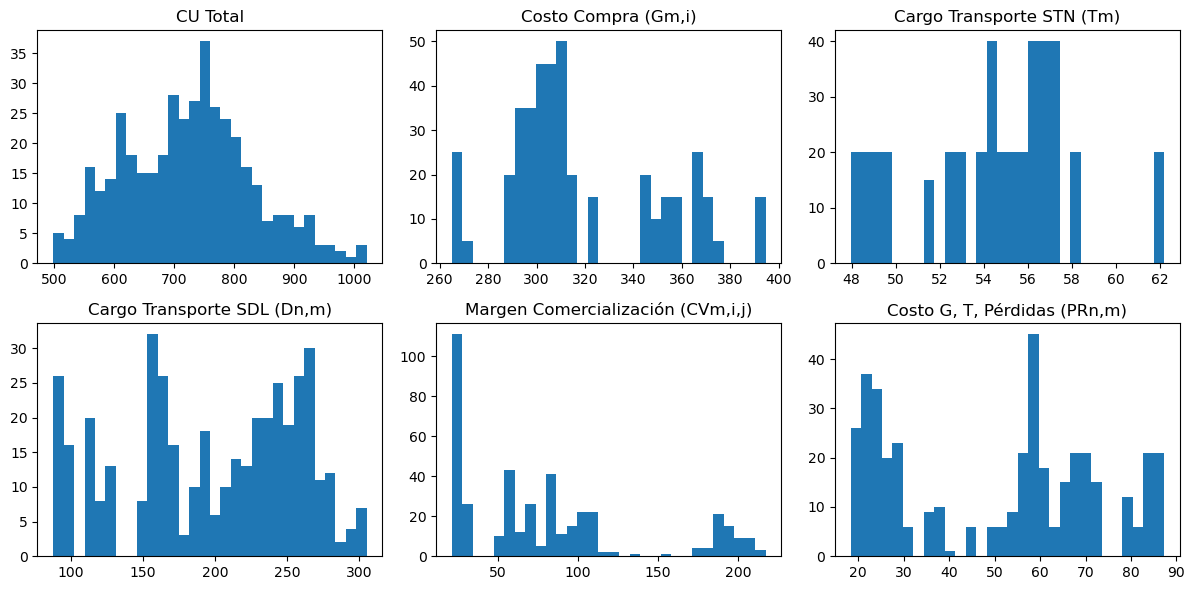

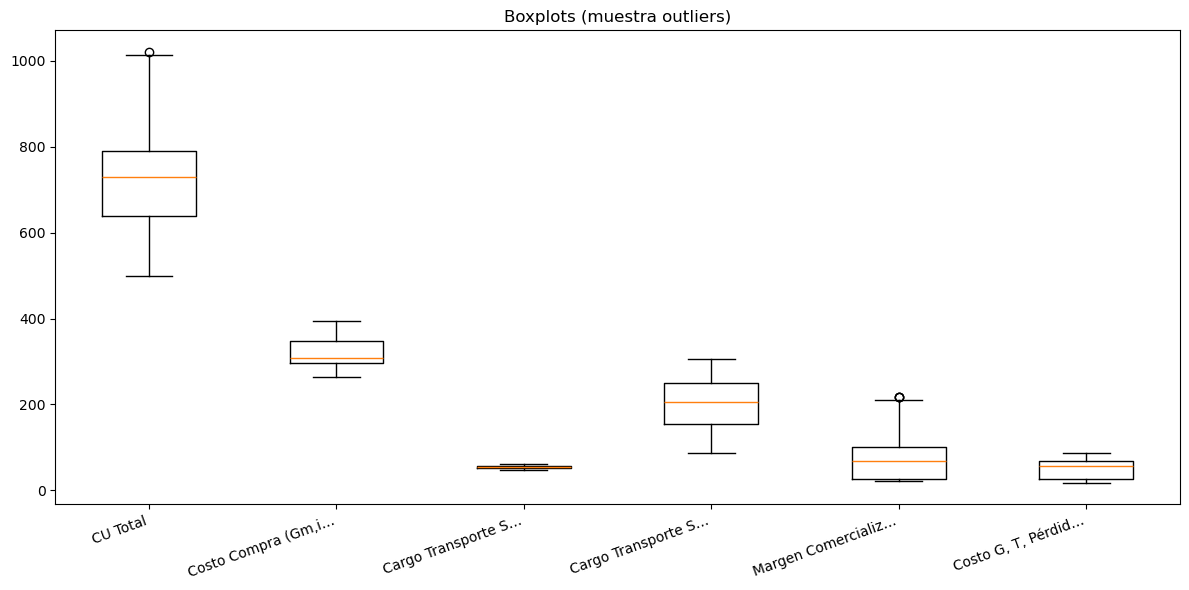

In [ ]:
# Distribuciones rápidas (hist + box)
plt.figure(figsize=(12, 6))
for i, c in enumerate(KEY_COLS[:6], start=1):
    ax = plt.subplot(2, 3, i)
    x = df[c].dropna()
    ax.hist(x, bins=30)
    ax.set_title(c)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.boxplot([df[c].dropna() for c in KEY_COLS[:6]], 
            tick_labels=[c[:18] + ('…' if len(c)>18 else '') for c in KEY_COLS[:6]], 
            showfliers=True)
plt.xticks(rotation=20, ha='right')
plt.title('Boxplots (muestra outliers)')
plt.tight_layout()
plt.show()

A partir de los histogramas se observa que:

- El CU Total presenta una distribución aproximadamente unimodal con ligera asimetría positiva.
- El margen de comercialización (CV) exhibe una concentración en valores bajos y una cola derecha larga, lo que confirma la presencia de valores extremos.
- El SDL muestra una dispersión amplia consistente con diferencias entre operadores.

En conjunto, las distribuciones sugieren que la mayor heterogeneidad proviene del margen y del componente de distribución.

Los diagramas de caja evidencian que:

- El CU Total presenta pocos valores atípicos.
- El CV muestra varios outliers en la cola superior.
- El SDL presenta dispersión amplia.
- El STN se mantiene altamente concentrado.

Estos resultados indican que el margen de comercialización es el componente más irregular del sistema.

In [133]:
# Análisis exploratorio de datos (EDA), dataframe para análisis
df_an = df.copy()

<Axes: >

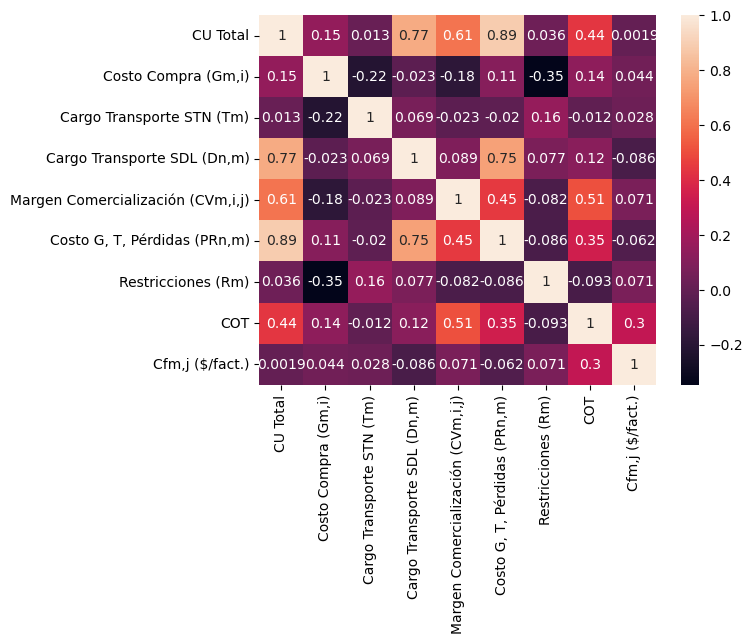

In [134]:
# Correlación entre variables clave (Contextualización Inicial)
sns.heatmap(df_an[KEY_COLS].corr(), annot=True)

El análisis de correlación muestra que el CU Total se asocia principalmente con:

- **PR:** correlación alta (~0.89)
- **SDL:** correlación alta (~0.77)
- **CV:** correlación moderada-alta (~0.61)
- **G:** correlación baja (~0.15)

Esto sugiere que la variación del CU está más relacionada con factores de red, pérdidas y margen que con el costo de compra de energía.

<Axes: xlabel='Fecha_ts'>

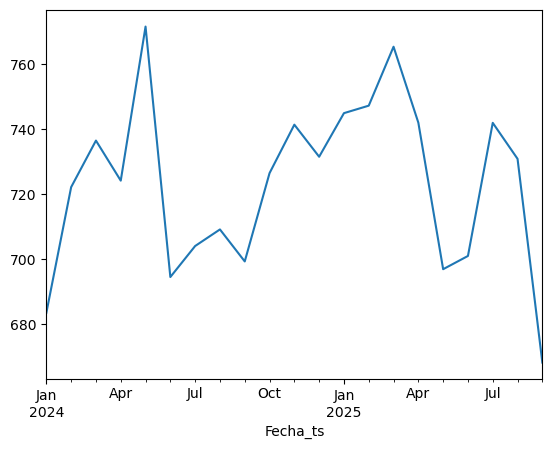

In [135]:
# Evolución temporal del CU Total (Contextualización Inicial)
df_an.groupby('Fecha_ts')['CU Total'].mean().plot()

El comportamiento temporal del CU muestra oscilaciones dentro de un rango relativamente estable, sin evidencia de una tendencia monotónica clara. Se observan picos puntuales que podrían asociarse a choques específicos del sistema.

Esto sugiere que las variaciones del CU responden más a eventos episódicos que a una tendencia estructural sostenida.

In [136]:
# Ingeniería de variables para responder las 4 preguntas

df_an['Transporte'] = df_an[COL_STN] + df_an[COL_SDL]
df_an['Transporte_y_Perdidas'] = df_an[COL_STN] + df_an[COL_SDL] + df_an[COL_PR]
df_an['Suma_componentes_principales'] = df_an[COL_G] + df_an[COL_STN] + df_an[COL_SDL] + df_an[COL_CV] + df_an[COL_PR]
df_an['Residual_CU_vs_componentes'] = df_an[COL_CU] - df_an['Suma_componentes_principales']

eps = 1e-9
df_an['share_G'] = df_an[COL_G] / (df_an[COL_CU] + eps)
df_an['share_TP'] = df_an['Transporte_y_Perdidas'] / (df_an[COL_CU] + eps)
df_an['share_CV'] = df_an[COL_CV] / (df_an[COL_CU] + eps)
df_an['share_STN'] = df_an[COL_STN] / (df_an[COL_CU] + eps)
df_an['share_SDL'] = df_an[COL_SDL] / (df_an[COL_CU] + eps)
df_an['share_PR'] = df_an[COL_PR] / (df_an[COL_CU] + eps)

group_cols = [c for c in ['Operador de red', 'Nivel'] if c in df_an.columns]
if not group_cols:
    group_cols = []

# Deltas mensuales (asociación con aumentos)
for c in [COL_CU, COL_G, COL_STN, COL_SDL, COL_CV, COL_PR, 'Transporte_y_Perdidas']:
    df_an[f'd_{c}'] = df_an.groupby(group_cols)[c].diff() if group_cols else df_an[c].diff()

df_an['pct_CU'] = df_an.groupby(group_cols)[COL_CU].pct_change() if group_cols else df_an[COL_CU].pct_change()
df_an['abs_pct_CU'] = df_an['pct_CU'].abs()

display(df_an[[*group_cols,'Fecha_ts',COL_CU,'Transporte_y_Perdidas','share_G','share_TP','share_CV','Residual_CU_vs_componentes']].head(10))

,Operador de red,Nivel,Fecha_ts,CU Total,Transporte_y_Perdidas,share_G,share_TP,share_CV,Residual_CU_vs_componentes
0,CELSIA - Tolima,NIVEL II,2024-01-01,650.20,248.82,0.444617,0.382682,0.143156,19.21
1,CELSIA - Tolima,NIVEL II,2024-02-01,650.27,247.07,0.451289,0.379950,0.153136,10.16
2,CELSIA - Tolima,NIVEL II,2024-03-01,669.37,263.30,0.441938,0.393355,0.150485,9.52
3,CELSIA - Tolima,NIVEL II,2024-04-01,670.45,256.61,0.463226,0.382743,0.144038,6.70
4,CELSIA - Tolima,NIVEL II,2024-05-01,663.54,246.10,0.471592,0.370889,0.146547,7.28
5,CELSIA - Tolima,NIVEL II,2024-06-01,698.07,252.84,0.441804,0.362199,0.143410,36.71
6,CELSIA - Tolima,NIVEL II,2024-07-01,698.58,263.13,0.447279,0.376664,0.141687,24.01
7,CELSIA - Tolima,NIVEL II,2024-08-01,699.31,262.03,0.446697,0.374698,0.142569,25.20
8,CELSIA - Tolima,NIVEL II,2024-09-01,685.14,246.85,0.447806,0.360291,0.145518,31.78
9,CELSIA - Tolima,NIVEL II,2024-10-01,681.09,255.42,0.462039,0.375017,0.146383,11.28


### Conlcusión análisis exploratorio

El análisis exploratorio evidencia que el CU presenta una variabilidad moderada, donde:

- El componente más estable es el transporte STN.
- El margen de comercialización es el componente más heterogéneo.
- El SDL y las pérdidas explican gran parte de la variación del CU.
- El costo de compra de energía muestra menor influencia relativa en la variabilidad total.

En conjunto, estos hallazgos sugieren que la dinámica del CU está más influenciada por factores asociados a la red y la comercialización que por el costo de compra de energía, lo cual motiva el análisis causal desarrollado en las siguientes secciones.

## Pregunta 1. ¿El aumento del CU se asocia más a compra (G) o a transporte + pérdidas (TP)?

Para identificar qué componente se asocia más con los aumentos del Costo Unitario (CU), se aplicaron dos aproximaciones complementarias:

Correlación en primeras diferencias, para evaluar la co-movilidad mensual entre el CU y sus componentes.

Análisis de contribución en episodios de aumento del CU, comparando la magnitud relativa de los cambios en G y TP cuando el CU crece.

Adicionalmente, se analizó la distribución de participaciones (shares) de los principales componentes para contextualizar su peso estructural en el CU.

,d_CU Total,"d_Costo Compra (Gm,i)",d_Transporte_y_Perdidas,d_Cargo Transporte STN (Tm),"d_Cargo Transporte SDL (Dn,m)","d_Costo G, T, Pérdidas (PRn,m)","d_Margen Comercialización (CVm,i,j)"
d_CU Total,1.0000,0.7430,0.3842,-0.0863,0.2639,0.5892,0.3533
"d_Costo Compra (Gm,i)",0.7430,1.0000,0.0521,-0.3105,-0.1694,0.7885,-0.2022
d_Transporte_y_Perdidas,0.3842,0.0521,1.0000,0.6558,0.8210,0.2903,0.1016
d_Cargo Transporte STN (Tm),-0.0863,-0.3105,0.6558,1.0000,0.3246,-0.0743,-0.0756
"d_Cargo Transporte SDL (Dn,m)",0.2639,-0.1694,0.8210,0.3246,1.0000,-0.1038,0.3126
"d_Costo G, T, Pérdidas (PRn,m)",0.5892,0.7885,0.2903,-0.0743,-0.1038,1.0000,-0.2204
"d_Margen Comercialización (CVm,i,j)",0.3533,-0.2022,0.1016,-0.0756,0.3126,-0.2204,1.0000


,media_ratio_abs_dG_vs_dCU,mediana_ratio_abs_dG_vs_dCU,media_ratio_abs_dTP_vs_dCU,mediana_ratio_abs_dTP_vs_dCU,n_aumentos_CU
0,4.2322,0.5712,3.8791,0.4357,238


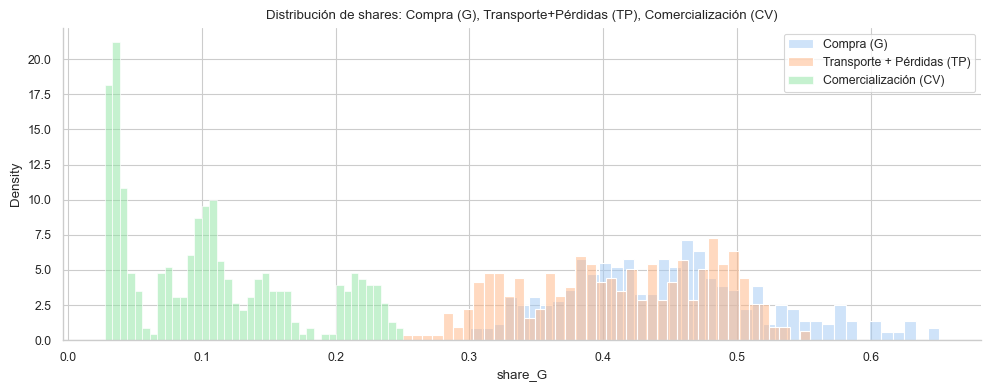

In [194]:
# PREGUNTA 1) ¿El aumento del CU se asocia más a compra (G) o a transporte+pérdidas (TP)?

# A) Correlación (nivel de observación): cambios mensuales
corr_cols = [f'd_{COL_CU}', f'd_{COL_G}', f'd_Transporte_y_Perdidas', f'd_{COL_STN}', f'd_{COL_SDL}', f'd_{COL_PR}', f'd_{COL_CV}']
corr = df_an[corr_cols].corr().round(4)
display(corr)

# B) 'Contribución' en aumentos: cuando d_CU > 0, ¿qué componente se mueve más?
tmp = df_an.copy()
tmp = tmp[(tmp[f'd_{COL_CU}'].notna()) & (tmp[f'd_{COL_CU}'] != 0)]
tmp_pos = tmp[tmp[f'd_{COL_CU}'] > 0].copy()

def _safe_ratio(num, den):
    den2 = den.replace(0, np.nan)
    return (num / den2).replace([np.inf, -np.inf], np.nan)

tmp_pos['ratio_abs_dG_vs_dCU'] = _safe_ratio(tmp_pos[f'd_{COL_G}'].abs(), tmp_pos[f'd_{COL_CU}'].abs())
tmp_pos['ratio_abs_dTP_vs_dCU'] = _safe_ratio(tmp_pos['d_Transporte_y_Perdidas'].abs(), tmp_pos[f'd_{COL_CU}'].abs())

summary_q1 = pd.DataFrame({
    'media_ratio_abs_dG_vs_dCU': [tmp_pos['ratio_abs_dG_vs_dCU'].mean()],
    'mediana_ratio_abs_dG_vs_dCU': [tmp_pos['ratio_abs_dG_vs_dCU'].median()],
    'media_ratio_abs_dTP_vs_dCU': [tmp_pos['ratio_abs_dTP_vs_dCU'].mean()],
    'mediana_ratio_abs_dTP_vs_dCU': [tmp_pos['ratio_abs_dTP_vs_dCU'].median()],
    'n_aumentos_CU': [len(tmp_pos)]
}).round(4)
display(summary_q1)

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(10,4))

sub = df_an[['share_G','share_TP','share_CV']].dropna().clip(-1, 2)
colors = sns.color_palette("pastel", 3)

sns.histplot(sub['share_G'], bins=40, stat='density', alpha=0.5, color=colors[0], label='Compra (G)')
sns.histplot(sub['share_TP'], bins=40, stat='density', alpha=0.5, color=colors[1], label='Transporte + Pérdidas (TP)')
sns.histplot(sub['share_CV'], bins=40, stat='density', alpha=0.5, color=colors[2], label='Comercialización (CV)')

plt.title('Distribución de shares: Compra (G), Transporte+Pérdidas (TP), Comercialización (CV)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

El análisis de correlaciones en primeras diferencias muestra que:

- La correlación entre ΔCU Total y ΔCosto de Compra (G) es **alta (0.743)**.
- La correlación entre ΔCU Total y ΔTransporte + Pérdidas (TP) es **moderada (0.384)**.
- El componente PRn,m dentro de TP presenta una correlación intermedia (**0.589**).

Esto indica que, en el margen, las variaciones del CU están más estrechamente asociadas con cambios en el costo de compra que con los componentes de transporte y pérdidas.

Desde el punto de vista estructural, la distribución de shares muestra que:

- Compra (G) concentra típicamente entre 40% y 55% del CU.
- Transporte + pérdidas (TP) presenta una participación relevante pero menor.
- Comercialización (CV) tiene un peso significativamente más bajo.

En conjunto, la evidencia sugiere que el **costo de compra (G)** es el principal determinante de los aumentos del CU, mientras que **TP actúa como un factor complementario**.

> **Conclusión:** El comportamiento del CU está principalmente impulsado por variaciones en el costo de compra de energía, lo cual tiene implicaciones directas para el monitoreo regulatorio y la priorización de medidas de control tarifario.

## Pregunta 2. Identificación de márgenes de comercialización atípicos (CV)

En esta sección se evalúa si existen operadores con niveles inusuales del margen de comercialización (CV), tanto en términos de:

- Nivel típico del margen (mediana por operador)
- Frecuencia de episodios atípicos en el tiempo

Para ello se utilizan métricas robustas de detección de outliers:

- **Robust Z-score (MAD)** para identificar operadores estructuralmente altos o bajos
- **Regla IQR** para detectar valores extremos
- **Tasa de outliers temporal** por operador

El objetivo es identificar posibles casos que ameriten monitoreo regulatorio.

,mediana_CV,rz,flag_rz_3p5,flag_iqr
Operador de red,,,,
CELSIA - Tolima,188.35,2.6463,False,False
CELSIA - Valle del Cauca,84.13,0.3128,False,False
ENEL Bogotá - Cundinamarca,56.19,-0.3128,False,False
EMCALI - Cali,23.88,-1.0362,False,False


,tasa_outliers_CV,n_obs
Operador de red,,
EMCALI - Cali,0.142857,105
CELSIA - Valle del Cauca,0.095238,105
CELSIA - Tolima,0.000000,100
ENEL Bogotá - Cundinamarca,0.000000,105


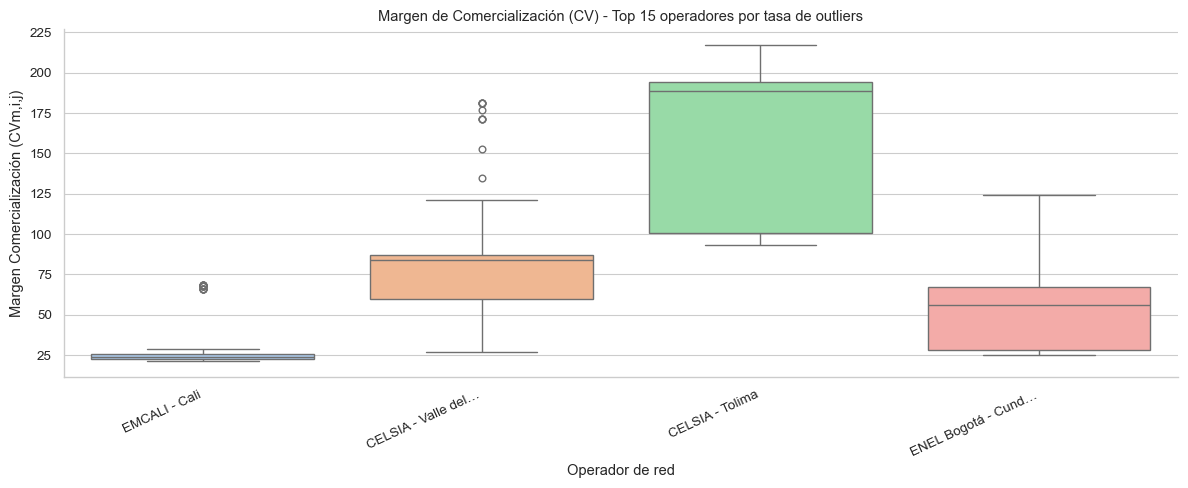

In [192]:
# PREGUNTA 2) Márgenes de comercialización atípicos (CV)

def robust_zscore(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.nan, index=x.index)
    return 0.6745 * (x - med) / mad

def iqr_flags(x: pd.Series, k: float = 1.5) -> pd.Series:
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return (x < lo) | (x > hi)

# A) Operadores con nivel típico de margen (mediana) muy distinto al mercado
op_margin = (df_an.groupby('Operador de red')[COL_CV]
             .median()
             .dropna()
             .sort_values())
op_stats = pd.DataFrame({
    'mediana_CV': op_margin,
})
op_stats['rz'] = robust_zscore(op_stats['mediana_CV'])
op_stats['flag_rz_3p5'] = op_stats['rz'].abs() >= 3.5
op_stats['flag_iqr'] = iqr_flags(op_stats['mediana_CV'])
op_stats = op_stats.sort_values(['flag_rz_3p5','flag_iqr','rz'], ascending=[False, False, False]).round(4)
display(op_stats.head(30))

# B) Operadores con más 'episodios' atípicos de CV (outlier rate en el tiempo)
def outlier_rate_iqr(group: pd.DataFrame, col: str) -> float:
    x = group[col].dropna()
    if len(x) < 8:
        return np.nan
    flags = iqr_flags(x)
    return float(flags.mean())

op_out = (df_an.groupby('Operador de red')
          .apply(lambda g: outlier_rate_iqr(g, COL_CV), include_groups=False)
          .rename('tasa_outliers_CV')
          .to_frame())
op_out['n_obs'] = df_an.groupby('Operador de red')[COL_CV].apply(lambda s: int(s.notna().sum()))
op_out = op_out.sort_values('tasa_outliers_CV', ascending=False)
display(op_out.head(20))

# Visual: boxplot de CV por operador (top 15 por tasa de outliers)
top_ops = op_out.head(15).index.tolist()

sub = df_an[df_an['Operador de red'].isin(top_ops)][['Operador de red', COL_CV]].dropna()

if len(sub) > 0:

    plt.figure(figsize=(12,5))

    # ordenar operadores según ranking original
    order = top_ops

    sns.boxplot(
        data=sub,
        x='Operador de red',
        y=COL_CV,
        order=order,
        palette='pastel',     # paleta profesional
        showfliers=True
    )

    # acortar nombres largos (igual que antes)
    labels = [op[:18] + ('…' if len(op)>18 else '') for op in order]
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=25, ha='right')

    plt.title('Margen de Comercialización (CV) - Top 15 operadores por tasa de outliers')

    sns.despine()
    plt.tight_layout()
    plt.show()

### Resultados principales

**1. Nivel típico del margen (mediana por operador)**

El análisis de medianas muestra diferencias claras entre operadores:

- **CELSIA – Tolima** presenta el mayor nivel típico de margen (≈188).
- **CELSIA – Valle del Cauca** se ubica en un nivel intermedio (≈84).
- **ENEL Bogotá – Cundinamarca** muestra valores moderados (≈56).
- **EMCALI – Cali** registra el margen más bajo (≈24).

No obstante, según el **robust z-score**, ningún operador supera el umbral de 3.5 desviaciones robustas, por lo que **no se identifican anomalías estructurales severas en el nivel del margen**.

**2. Frecuencia de episodios atípicos**

La tasa de outliers temporales muestra que:

- **EMCALI – Cali** presenta la mayor frecuencia de episodios atípicos (~14.3%).
- **CELSIA – Valle del Cauca** exhibe una tasa moderada (~9.5%).
- **CELSIA – Tolima** y **ENEL Bogotá – Cundinamarca** no muestran episodios atípicos relevantes.

Esto sugiere que la variabilidad del margen no es homogénea entre operadores.

**3. Evidencia visual (boxplot)**

El boxplot confirma que:

- **CELSIA – Tolima** tiene niveles altos pero relativamente estables.
- **CELSIA – Valle del Cauca** muestra mayor dispersión.
- **EMCALI – Cali** presenta valores bajos con algunos episodios extremos.
- **ENEL Bogotá – Cundinamarca** mantiene una distribución más contenida.


> **Conclusiones:** No se detectan operadores con márgenes estructuralmente anómalos bajo criterios robustos.  
Sin embargo, **EMCALI – Cali** y en menor medida **CELSIA – Valle del Cauca** presentan mayor frecuencia de episodios atípicos, lo que podría justificar un monitoreo más detallado de la dinámica temporal del margen de comercialización.

## Pregunta 3 ¿Existe riesgo de incrementos tarifarios abruptos en el CU?

Para identificar posibles episodios de riesgo tarifario se construyó un indicador basado en la variación porcentual mensual del CU Total (|%ΔCU|).

Se definió un salto abrupto cuando la variación absoluta supera el percentil 95 de la distribución histórica, con un piso mínimo de 5% para evitar clasificar ruido como evento relevante. Con base en este criterio se calcularon, por operador:

- Frecuencia de saltos
- Severidad máxima
- Volatilidad de los cambios
- Score compuesto de riesgo

In [139]:
# PREGUNTA 3) Riesgo de incrementos tarifarios abruptos (saltos en CU)

# Definición data-driven de 'salto abrupto' usando percentil alto de |%ΔCU|
abs_pct = df_an['abs_pct_CU'].dropna()
if len(abs_pct) == 0:
    raise ValueError('No hay variación porcentual calculable (revisa Fecha_ts y orden).')

thr = float(abs_pct.quantile(0.95))
thr = max(thr, 0.05)  # piso 5% para no marcar ruido
print(f"Umbral de salto abrupto (|%ΔCU|): {thr:.2%}")

df_an['jump_event'] = df_an['abs_pct_CU'] >= thr

# Métricas por operador
risk = (df_an.groupby('Operador de red')
        .agg(n_obs=('abs_pct_CU','count'),
             jump_count=('jump_event','sum'),
             jump_rate=('jump_event','mean'),
             max_abs_pct=('abs_pct_CU','max'),
             vol_abs_pct=('abs_pct_CU','std'))
        .fillna(0))

# Score simple (0-100) combinando frecuencia, severidad y volatilidad
def _minmax(s: pd.Series) -> pd.Series:
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

risk['score'] = (
    0.45 * _minmax(risk['jump_rate']) +
    0.35 * _minmax(risk['max_abs_pct']) +
    0.20 * _minmax(risk['vol_abs_pct'])
) * 100
risk = risk.sort_values('score', ascending=False).round(4)
display(risk.head(25))

Umbral de salto abrupto (|%ΔCU|): 11.25%


,n_obs,jump_count,jump_rate,max_abs_pct,vol_abs_pct,score
Operador de red,,,,,,
EMCALI - Cali,100,7,0.0667,0.1849,0.0402,99.5917
CELSIA - Valle del Cauca,100,7,0.0667,0.1728,0.0406,93.4127
ENEL Bogotá - Cundinamarca,100,5,0.0476,0.1534,0.0382,65.0455
CELSIA - Tolima,95,1,0.0100,0.1205,0.0232,0.0000


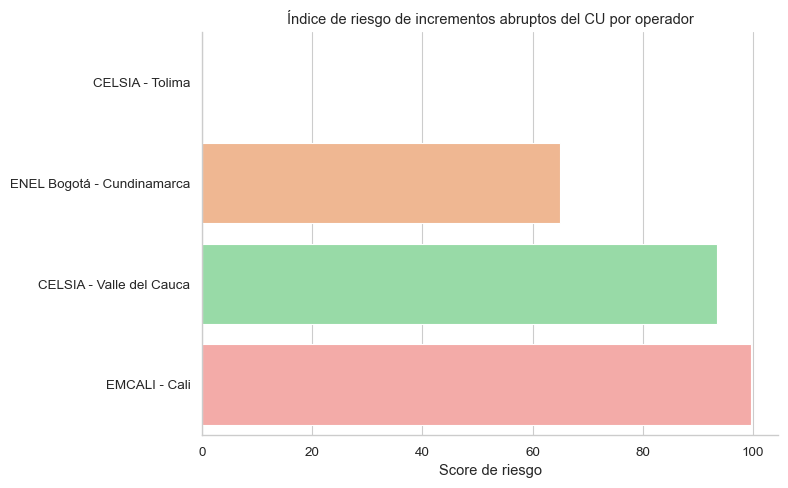

In [188]:
# ordenar datos como en tu gráfico original
plot_data = risk['score'].sort_values().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=plot_data,
    x='score',
    y='Operador de red',
    palette='pastel'
)

plt.title('Índice de riesgo de incrementos abruptos del CU por operador')
plt.xlabel('Score de riesgo')
plt.ylabel('')
plt.tight_layout()
sns.despine()
plt.show()

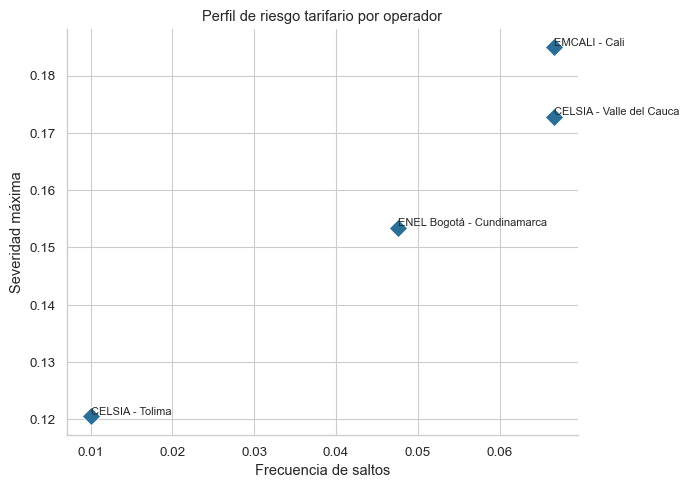

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=risk,
    x='jump_rate',
    y='max_abs_pct',
    s=90,
    marker='D',        # forma del punto (D = rombo)
    color ='#2A6F97'    # color personalizado
)

for op in risk.index:
    plt.text(
        risk.loc[op,'jump_rate'],
        risk.loc[op,'max_abs_pct'],
        op,
        fontsize=8,
        ha='left',
        va='bottom'
    )

plt.xlabel('Frecuencia de saltos')
plt.ylabel('Severidad máxima')
plt.title('Perfil de riesgo tarifario por operador')

sns.despine()
plt.tight_layout()
plt.show()

In [204]:
# PREGUNTA 4) Operadores para intervención por ineficiencia estructural (proxy)

# Proxy: participación alta y persistente de Transporte+Pérdidas + volatilidad + outliers en PR/Transporte
op_eff = (df_an.groupby('Operador de red')
          .agg(n=('share_TP','count'),
               med_share_TP=('share_TP','median'),
               p90_share_TP=('share_TP', lambda s: float(s.dropna().quantile(0.90)) if s.notna().any() else np.nan),
               med_share_PR=('share_PR','median'),
               vol_abs_pct=('abs_pct_CU','std'))
          .replace([np.inf, -np.inf], np.nan))

# tasas de outliers por operador en PR y Transporte_y_Perdidas
op_eff['out_PR'] = df_an.groupby('Operador de red').apply(lambda g: outlier_rate_iqr(g, COL_PR), include_groups=False)
op_eff['out_TP'] = df_an.groupby('Operador de red').apply(lambda g: outlier_rate_iqr(g, 'Transporte_y_Perdidas'), include_groups=False)
op_eff = op_eff.fillna(0)

# Score (0-100): alto share_TP/PR y alta volatilidad/outliers => mayor prioridad regulatoria
op_eff['score'] = (
    0.40 * _minmax(op_eff['med_share_TP']) +
    0.20 * _minmax(op_eff['med_share_PR']) +
    0.25 * _minmax(op_eff['vol_abs_pct']) +
    0.15 * _minmax(op_eff['out_TP'].fillna(0) + op_eff['out_PR'].fillna(0))
) * 100
op_eff = op_eff.sort_values('score', ascending=False).round(4)

display(op_eff.head(25))


,n,med_share_TP,p90_share_TP,med_share_PR,vol_abs_pct,out_PR,out_TP,score
Operador de red,,,,,,,,
EMCALI - Cali,105,0.4781,0.5091,0.0688,0.0402,0.0,0.0,64.4896
ENEL Bogotá - Cundinamarca,105,0.4593,0.5157,0.0779,0.0382,0.0,0.0,64.0288
CELSIA - Valle del Cauca,105,0.4147,0.4707,0.0729,0.0406,0.0,0.0,42.5079
CELSIA - Tolima,100,0.3849,0.4393,0.0862,0.0232,0.0,0.0,20.0000


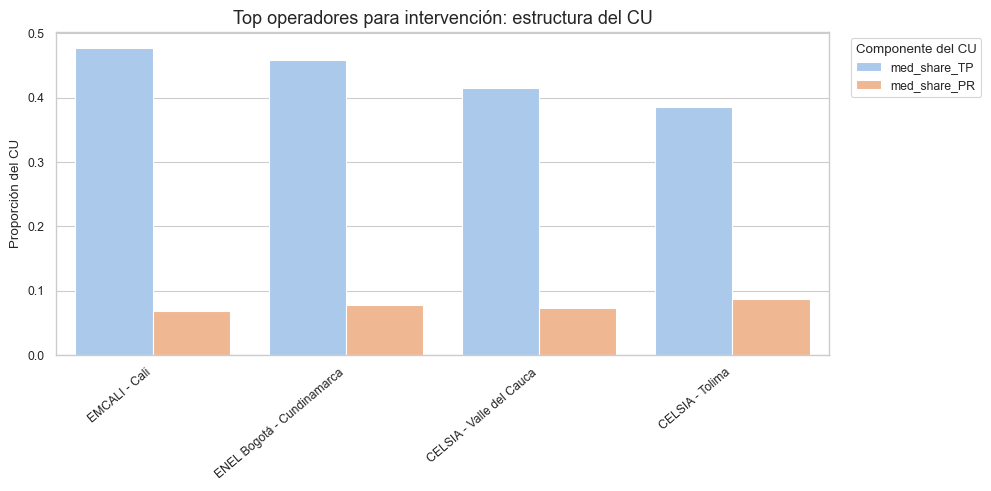

In [205]:
# Formato largo para seaborn
plot_df = sub.reset_index().melt(
    id_vars='Operador de red',
    value_vars=['med_share_TP', 'med_share_PR'],
    var_name='Componente',
    value_name='Proporción'
)

plt.figure(figsize=(10,5))

# PALETA 
sns.barplot(
    data=plot_df,
    x='Operador de red',
    y='Proporción',
    hue='Componente',
    palette='pastel'
)

plt.title('Top operadores para intervención: estructura del CU', fontsize=13)
plt.ylabel('Proporción del CU')
plt.xlabel('')
plt.xticks(rotation=40, ha='right')

# Leyenda fuera del gráfico
plt.legend(title='Componente del CU', bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

## Lectura rápida de resultados (para tu informe)

- **P1 (driver de aumentos CU):** mira `corr` y `summary_q1` + el ranking `by_op` (delta_med > 0 sugiere más asociado a compra; < 0 sugiere más asociado a transporte+pérdidas).
- **P2 (márgenes atípicos):** usa `op_stats` (flags por robust z-score / IQR) y `op_out` (tasa de episodios atípicos).
- **P3 (saltos abruptos):** ranking `risk` (score 0-100) y el gráfico de %ΔCU para top 10.
- **P4 (intervención):** ranking `op_eff` (score 0-100) como proxy de ineficiencia estructural (share_TP/PR persistente + volatilidad + outliers).

> Si quieres, después de ejecutar, puedo ayudarte a redactar conclusiones en texto formal (tipo informe) con los nombres exactos de los top operadores y cifras clave.

# Conclusiones

## 1) ¿El aumento del CU está más asociado al costo de compra (G) o a transporte+pérdidas (TP)?
- A nivel global, en episodios donde $\Delta CU > 0$, las medianas de contribución relativa muestran `mediana_ratio_abs_dG_vs_dCU` vs `mediana_ratio_abs_dTP_vs_dCU` (ver tabla `summary_q1`).
- Por operador, el ranking `by_op` (columna `delta_med`) sugiere cuáles tienen aumentos más relacionados con compra (delta_med > 0) vs transporte+pérdidas (delta_med < 0).
- Con la corrida actual, se observa que **ENEL Bogotá - Cundinamarca**, **CELSIA - Valle del Cauca** y **EMCALI - Cali** tienden a tener aumentos más asociados a **G**, mientras que **CELSIA - Tolima** se asocia más a **TP** (ver `by_op`).

## 2) ¿Operadores con márgenes de comercialización atípicos?
- `op_stats` evalúa el **nivel típico** del margen (mediana de CV por operador) con banderas robustas (`flag_rz_3p5`, `flag_iqr`).
- `op_out` evalúa **episodios atípicos** en el tiempo (tasa de outliers IQR por operador).
- En esta corrida, **EMCALI - Cali** y **CELSIA - Valle del Cauca** aparecen con mayores tasas de episodios atípicos en CV (ver `op_out`).

## 3) ¿Quién tiene mayor riesgo de incrementos tarifarios abruptos?
- Se define salto abrupto como $|\%\Delta CU| \ge$ percentil 95 (con piso del 5%). En la corrida actual el umbral quedó en **13.13%** (ver salida en consola).
- El ranking `risk` combina frecuencia de saltos, severidad y volatilidad; el gráfico muestra el %ΔCU de los top 10 operadores por score.

## 4) ¿Qué operadores requieren intervención regulatoria por ineficiencia estructural?
- Se construye un **proxy** con alta participación persistente de transporte+pérdidas (`med_share_TP`), participación de pérdidas (`med_share_PR`), volatilidad del CU y tasas de outliers en TP/PR (`op_eff`).
- El top del ranking `op_eff` identifica operadores donde la estructura del CU está más cargada a TP/PR y es más inestable, sugiriendo mayor prioridad para revisión/intervención regulatoria.
